In [212]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
from itertools import product
from matplotlib import pyplot as plt
from scipy.stats import shapiro #Test estadistico sobre la normalidad de los residuos
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

import warnings
from sklearn.exceptions import ConvergenceWarning
#warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

In [213]:
channel_name = "channel_1055"
df = pd.read_csv('https://raw.githubusercontent.com/PabloSoligo2014/3670-UNLaM-CD/refs/heads/main/datasets/channel_1055.csv', index_col="Timestamp", parse_dates=True)

In [214]:
df.head()

,channel_1055,Unit_measure,Subsystem
Timestamp,,,
2025-01-01 00:00:00,0.496714,UnitMeasure5,Subsystem1
2025-01-01 00:00:30,0.904835,UnitMeasure5,Subsystem1
2025-01-01 00:01:00,1.698462,UnitMeasure5,Subsystem1
2025-01-01 00:01:30,3.863408,UnitMeasure5,Subsystem1
2025-01-01 00:02:00,5.621446,UnitMeasure5,Subsystem1


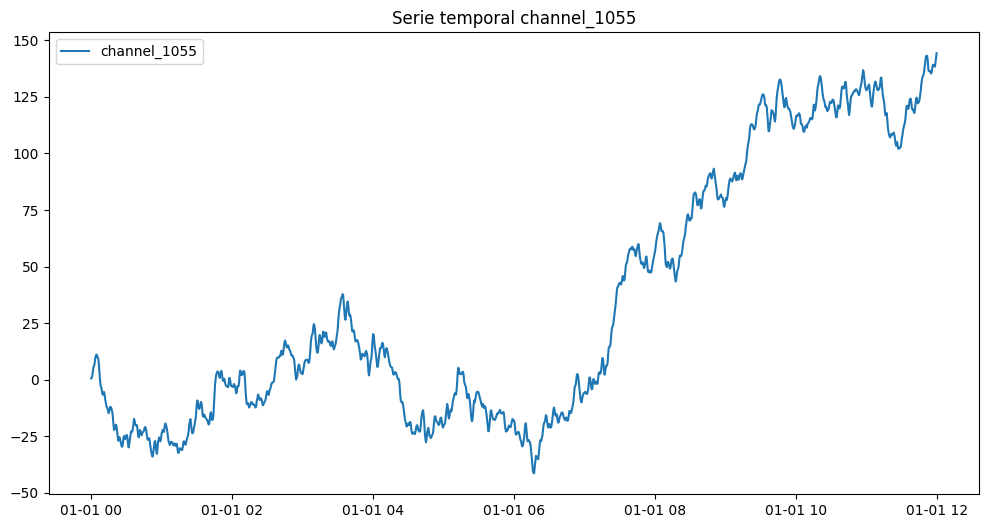

In [215]:
plt.figure(figsize=(12,6))
plt.plot(df["channel_1055"], label=channel_name)
plt.title(f'Serie temporal {channel_name}')
plt.legend()
plt.show()

¿Hay nulos?

In [216]:
#Si, columnas hay una sola, pero lo dejamos genérico para otros casos
for c in df.columns:
    print(f"{c}: {df[c].isnull().sum()} nulos")

channel_1055: 0 nulos
Unit_measure: 0 nulos
Subsystem: 0 nulos


¿Hay duplicados?

In [217]:
df.index.duplicated().any() 

np.False_

¿La periodicidad es estable?

In [218]:
df_time_diffs = df.index.to_series().diff().dt.total_seconds()  
print(df_time_diffs.value_counts())

Timestamp
30.0    1353
60.0      43
Name: count, dtype: int64


---------------------

### 1. Si la periodicidad no es estable, resolver



Resample a frecuencia horaria y rellenar valores faltantes

In [219]:
# Asegurar que la columna sea numérica antes de interpolar
df[channel_name] = pd.to_numeric(df[channel_name], errors='coerce')

# Resample a frecuencia horaria y rellenar valores faltantes
df = df.resample('h').interpolate(method='linear')

print(f"Después del resample: {df.shape[0]} registros")
print(f"Valores no nulos en {channel_name}: {df[channel_name].notna().sum()}")
print(f"Rango de fechas: {df.index.min()} a {df.index.max()}")

Después del resample: 12 registros
Valores no nulos en channel_1055: 12
Rango de fechas: 2025-01-01 00:00:00 a 2025-01-01 11:00:00


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14764\930833890.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.resample('h').interpolate(method='linear')


### 2. ¿Tiene la serie propiedades para poder aplicar un modelo estadístico? Verificar y actuar en consecuencia.

Test de Dickey-Fuller para verificar estacionariedad

In [220]:
def test_stationarity(timeseries, column_name):
    result = adfuller(timeseries.dropna())
    print(f'--- Test de Dickey-Fuller para {column_name} ---')
    print(f'Estadístico ADF: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Valores críticos:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.3f}')
    if result[1] <= 0.05:
        print("La serie ES estacionaria (rechazamos H0)")
    else:
        print("La serie NO es estacionaria (no rechazamos H0)")
    return result[1] <= 0.05

Probar con la serie original

In [221]:
is_stationary = test_stationarity(df[channel_name], channel_name)

--- Test de Dickey-Fuller para channel_1055 ---
Estadístico ADF: 2.617920
p-value: 0.999078
Valores críticos:
	1%: -4.665
	5%: -3.367
	10%: -2.803
La serie NO es estacionaria (no rechazamos H0)


Si no es estacionaria, aplicar diferenciación


--- Después de una diferenciación ---
--- Test de Dickey-Fuller para diff_1 ---
Estadístico ADF: 0.768798
p-value: 0.991115
Valores críticos:
	1%: -4.939
	5%: -3.478
	10%: -2.844
La serie NO es estacionaria (no rechazamos H0)


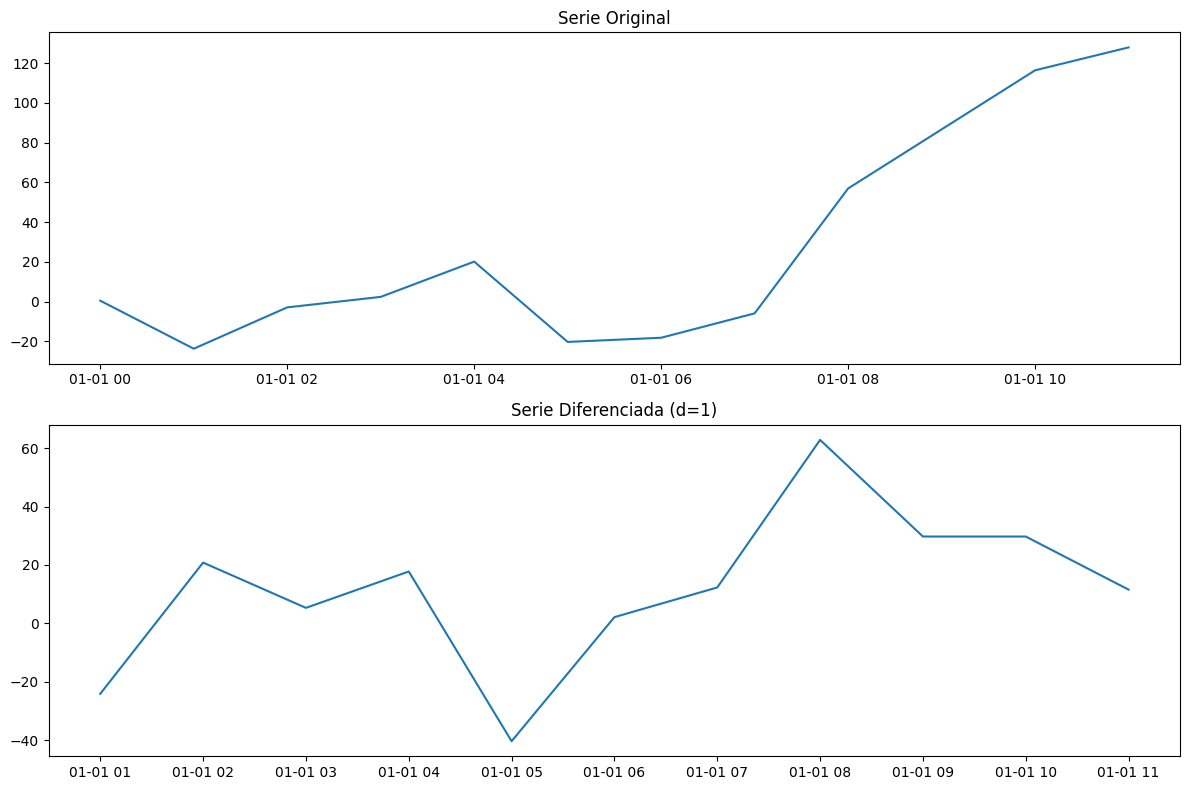

In [222]:
if not is_stationary:
    df['diff_1'] = df[channel_name].diff()
    print("\n--- Después de una diferenciación ---")
    test_stationarity(df['diff_1'], 'diff_1')
    
    # Visualizar
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    axes[0].plot(df[channel_name])
    axes[0].set_title('Serie Original')
    axes[1].plot(df['diff_1'])
    axes[1].set_title('Serie Diferenciada (d=1)')
    plt.tight_layout()
    plt.show()

### 3. ¿Puede encontrar un modelo que supere el pronóstico ingenuo que agregamos al pie?

Primero, analizar ACF y PACF para tener una idea inicial

Calcular el número máximo de lags basado en el tamaño de los datos

Usando 5 lags para ACF/PACF


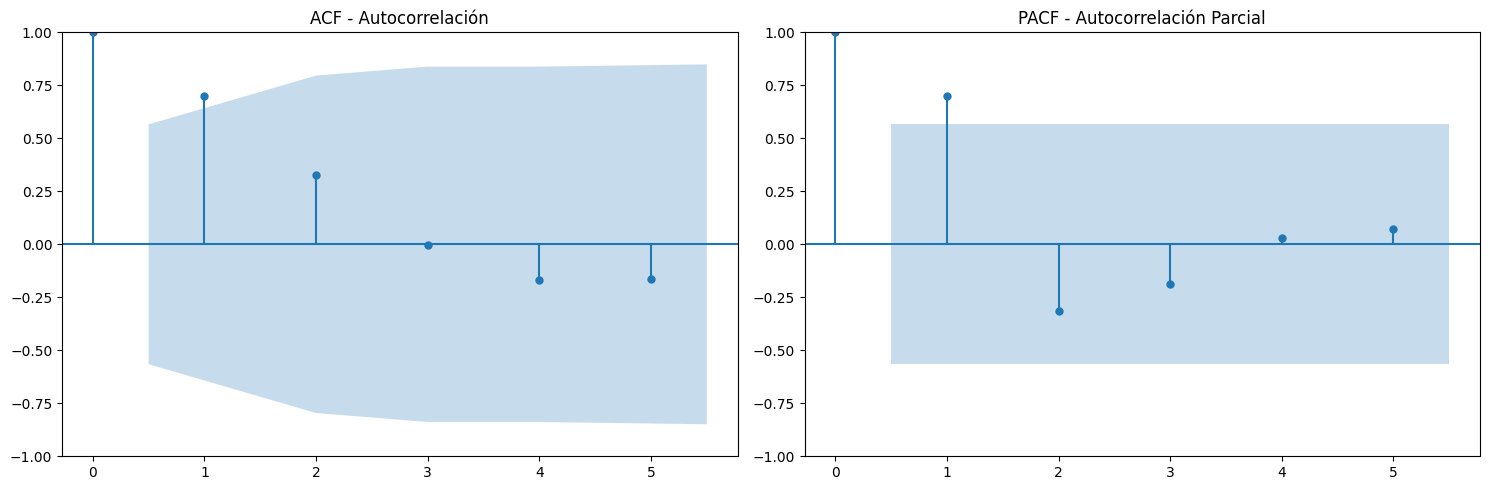

In [223]:
max_lags = min(40, len(df[channel_name].dropna()) // 2 - 1)
print(f"Usando {max_lags} lags para ACF/PACF")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(df[channel_name].dropna(), lags=max_lags, ax=axes[0])
axes[0].set_title('ACF - Autocorrelación')
plot_pacf(df[channel_name].dropna(), lags=max_lags, ax=axes[1])
axes[1].set_title('PACF - Autocorrelación Parcial')
plt.tight_layout()
plt.show()

Dividir en train y test

In [224]:
train_size = int(len(df) * 0.8)
train = df[:train_size]
test = df[train_size:]

print(f"Train: {len(train)} registros")
print(f"Test: {len(test)} registros")

Train: 9 registros
Test: 3 registros


Búsqueda de parámetros (restringida según ACF/PACF)

Basándonos en los gráficos, limitamos la búsqueda

In [225]:
p_range = range(0, 4)  # AR
d_range = range(0, 2)  # Diferenciación
q_range = range(0, 4)  # MA

Componente estacional (si aplica)

In [226]:
P_range = range(0, 2)
D_range = range(0, 2)
Q_range = range(0, 2)
s = 24  # Periodicidad diaria (24 horas)

In [227]:
print("Iniciando búsqueda de parámetros óptimos...")

best_aic = np.inf
best_params = None
best_seasonal_params = None
results_list = []

# Búsqueda en grid (limitada)
for params in product(p_range, d_range, q_range):
    for seasonal_params in product(P_range, D_range, Q_range):
        try:
            model = SARIMAX(train[channel_name],
                          order=params,
                          seasonal_order=(*seasonal_params, s),
                          enforce_stationarity=False,
                          enforce_invertibility=False)
            
            fitted_model = model.fit(disp=False, maxiter=200)
            
            results_list.append({
                'order': params,
                'seasonal_order': (*seasonal_params, s),
                'AIC': fitted_model.aic,
                'BIC': fitted_model.bic
            })
            
            if fitted_model.aic < best_aic:
                best_aic = fitted_model.aic
                best_params = params
                best_seasonal_params = (*seasonal_params, s)
                
        except Exception as e:
            continue

print(f"\n✓ Mejor modelo encontrado:")
print(f"  SARIMA{best_params}x{best_seasonal_params}")
print(f"  AIC: {best_aic:.2f}")

Iniciando búsqueda de parámetros óptimos...

✓ Mejor modelo encontrado:
  SARIMA(0, 0, 0)x(0, 1, 0, 24)
  AIC: 2.00

✓ Mejor modelo encontrado:
  SARIMA(0, 0, 0)x(0, 1, 0, 24)
  AIC: 2.00


Mostrar top 5 modelos

In [228]:
results_df = pd.DataFrame(results_list).sort_values('AIC').head(10)
print("\nTop 10 modelos por AIC:")
print(results_df.to_string())


Top 10 modelos por AIC:
        order seasonal_order  AIC  BIC
2   (0, 0, 0)  (0, 1, 0, 24)  2.0  NaN
34  (0, 1, 0)  (0, 1, 0, 24)  2.0  NaN
3   (0, 0, 0)  (0, 1, 1, 24)  4.0  NaN
1   (0, 0, 0)  (0, 0, 1, 24)  4.0  NaN
6   (0, 0, 0)  (1, 1, 0, 24)  4.0  NaN
10  (0, 0, 1)  (0, 1, 0, 24)  4.0  NaN
33  (0, 1, 0)  (0, 0, 1, 24)  4.0  NaN
4   (0, 0, 0)  (1, 0, 0, 24)  4.0  NaN
36  (0, 1, 0)  (1, 0, 0, 24)  4.0  NaN
35  (0, 1, 0)  (0, 1, 1, 24)  4.0  NaN


Entrenar el mejor modelo y hacer predicciones

In [229]:
best_model = SARIMAX(train[channel_name],
                     order=best_params,
                     seasonal_order=best_seasonal_params,
                     enforce_stationarity=False,
                     enforce_invertibility=False)

fitted_best_model = best_model.fit(disp=False, maxiter=200)
print(fitted_best_model.summary())

                                SARIMAX Results                                 
Dep. Variable:             channel_1055   No. Observations:                    9
Model:             SARIMAX(0, 1, 0, 24)   Log Likelihood                   0.000
Date:                  Fri, 21 Nov 2025   AIC                              2.000
Time:                          02:54:27   BIC                                nan
Sample:                      01-01-2025   HQIC                               nan
                           - 01-01-2025                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2          1e-10          0        inf      0.000       1e-10       1e-10
Ljung-Box (L1) (Q):                    nan   Jarque-Bera (JB):                  nan
Prob(Q):                       

Hacer predicciones y calcular métricas

Hacer predicciones en el conjunto de test

In [230]:
predictions = fitted_best_model.forecast(steps=len(test))

Calcular métricas

In [231]:
mae = np.mean(np.abs(test[channel_name] - predictions))
rmse = np.sqrt(np.mean((test[channel_name] - predictions)**2))
mape = np.mean(np.abs((test[channel_name] - predictions) / test[channel_name])) * 100
print(f"\n--- Métricas del modelo SARIMAX ---")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")


--- Métricas del modelo SARIMAX ---
MAE: 110.31
RMSE: 111.67
MAPE: 100.00%


Modelo ingenuo (benchmark) - usa el último valor conocido

In [232]:
naive_predictions = train[channel_name].iloc[-1]
mae_naive = np.mean(np.abs(test[channel_name] - naive_predictions))
print(f"\n--- Modelo Ingenuo (Naive Forecast) ---")
print(f"MAE Modelo Ingenuo: {mae_naive:.2f}")
print(f"\nMejora sobre modelo ingenuo: {((mae_naive - mae) / mae_naive * 100):.2f}%")
if mae < mae_naive:
    print(f"El modelo SARIMAX SUPERA al pronóstico ingenuo")
else:
    print(f"El modelo SARIMAX NO supera al pronóstico ingenuo")


--- Modelo Ingenuo (Naive Forecast) ---
MAE Modelo Ingenuo: 53.37

Mejora sobre modelo ingenuo: -106.70%
El modelo SARIMAX NO supera al pronóstico ingenuo


Visualizar predicciones vs valores reales

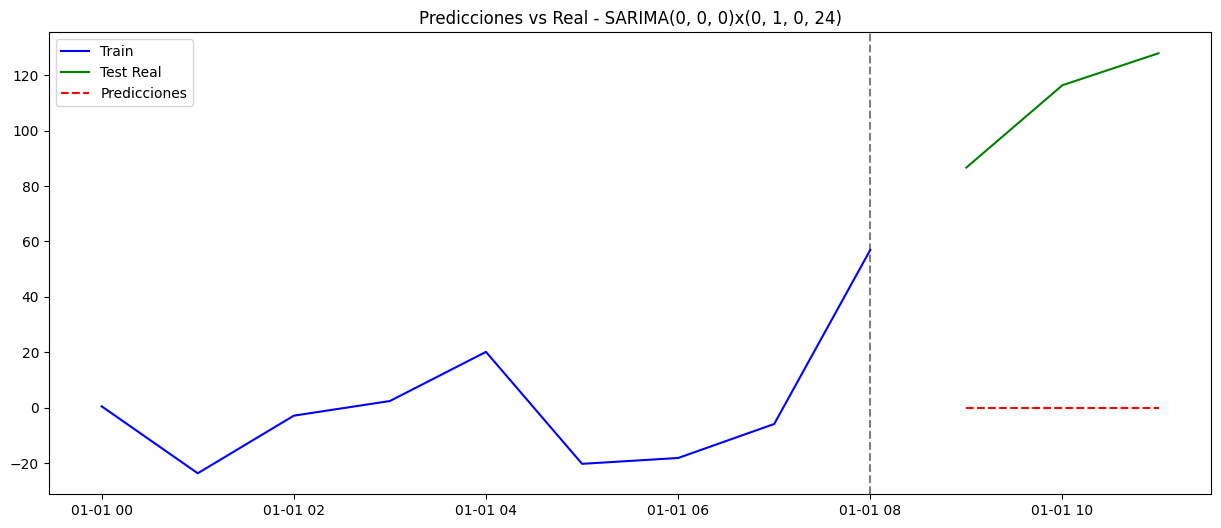

In [233]:
plt.figure(figsize=(15, 6))
plt.plot(train.index, train[channel_name], label='Train', color='blue')
plt.plot(test.index, test[channel_name], label='Test Real', color='green')
plt.plot(test.index, predictions, label='Predicciones', color='red', linestyle='--')
plt.axvline(x=train.index[-1], color='black', linestyle='--', alpha=0.5)
plt.title(f'Predicciones vs Real - SARIMA{best_params}x{best_seasonal_params}')
plt.legend()
plt.show()

### 4. Si intenta una búsqueda de orden p y q ¿Puede restringir al menos un poco las opciones de búsqueda?

![alt text](https://raw.githubusercontent.com/PabloSoligo2014/3670-UNLaM-CD/04a3bf4de29e852538ff7346b73958d5d8427a95/09_TimeSeries/image.png)

**Respuesta**: Sí, usando los gráficos ACF y PACF podemos restringir la búsqueda:

- **ACF (Autocorrelación)**: Si decae exponencialmente, sugiere un componente AR. Si hay un corte abrupto después de q lags, sugiere MA(q).
- **PACF (Autocorrelación Parcial)**: Si hay un corte abrupto después de p lags, sugiere AR(p). Si decae exponencialmente, sugiere componente MA.

En nuestro código, restringimos:
- `p` (AR): 0-3
- `d` (diferenciación): 0-1  
- `q` (MA): 0-3
- Componente estacional: P, D, Q = 0-1 con s=24 (periodicidad horaria/diaria)

Esto reduce significativamente el espacio de búsqueda de cientos a decenas de modelos.

### 5. ¿Los residuos del pronóstico son aproximadamente normales?

Para responder esta pregunta, debemos analizar los residuos del modelo ajustado.

#### Análisis de residuos del modelo

Obtener residuos del modelo

In [234]:
residuals = fitted_best_model.resid

Calcular el número máximo de lags para ACF de residuos

In [235]:
max_lags_resid = min(40, len(residuals) // 2 - 1)

#### Visualización completa de diagnóstico de residuos

La siguiente celda crea 4 gráficos:
- **Residuos en el tiempo**: Detecta patrones temporales
- **Histograma con curva normal**: Compara distribución de residuos con normal teórica
- **Q-Q Plot**: Evalúa normalidad visualmente
- **ACF de residuos**: Verifica independencia (ausencia de autocorrelación)

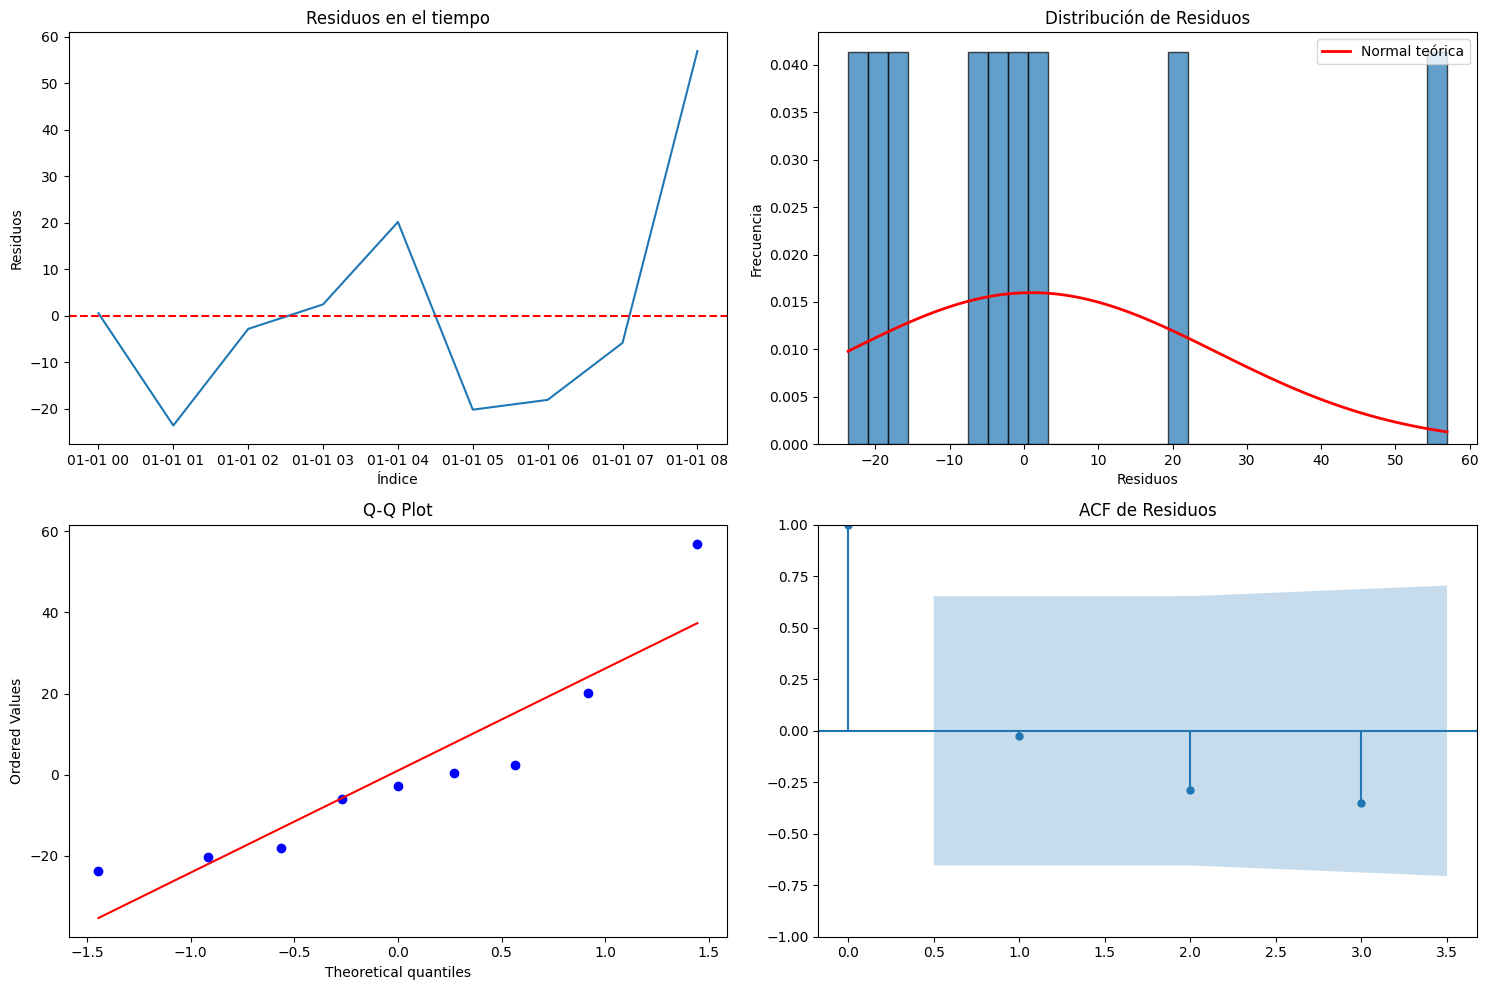

In [236]:
# Crear figura con 4 subgráficos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 5.1 - Serie de residuos en el tiempo
axes[0, 0].plot(residuals)
axes[0, 0].set_title('Residuos en el tiempo')
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Índice')
axes[0, 0].set_ylabel('Residuos')

# 5.2 - Histograma de residuos con curva normal teórica
axes[0, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7, density=True)
mu, sigma = residuals.mean(), residuals.std()
x = np.linspace(residuals.min(), residuals.max(), 100)
axes[0, 1].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal teórica')
axes[0, 1].set_title('Distribución de Residuos')
axes[0, 1].set_xlabel('Residuos')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].legend()

# 5.3 - Q-Q plot (cuantil-cuantil)
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot')

# 5.4 - ACF de residuos
plot_acf(residuals, lags=max_lags_resid, ax=axes[1, 1])
axes[1, 1].set_title('ACF de Residuos')

plt.tight_layout()
plt.show()

#### Test estadístico de normalidad (Shapiro-Wilk)

Test de normalidad de Shapiro-Wilk

In [ ]:
shapiro_stat, shapiro_p = shapiro(residuals)
print(f"\n--- Test de Shapiro-Wilk (Normalidad de Residuos) ---")
print(f"Estadístico: {shapiro_stat:.6f}")
print(f"p-value: {shapiro_p:.6f}")
if shapiro_p > 0.05:
    print("Los residuos parecen seguir una distribución normal")
else:
    print("Los residuos NO siguen una distribución normal")


--- Test de Shapiro-Wilk (Normalidad de Residuos) ---
Estadístico: 0.853160
p-value: 0.080727
Los residuos parecen seguir una distribución normal


Estadísticas descriptivas de residuos

In [238]:
print(f"\n--- Estadísticas de Residuos ---")
print(f"Media: {residuals.mean():.6f}")
print(f"Desviación estándar: {residuals.std():.6f}")
print(f"Sesgo: {residuals.skew():.6f}")
print(f"Curtosis: {residuals.kurtosis():.6f}")


--- Estadísticas de Residuos ---
Media: 1.024113
Desviación estándar: 24.967374
Sesgo: 1.546654
Curtosis: 2.753218


![alt text](https://raw.githubusercontent.com/PabloSoligo2014/3670-UNLaM-CD/04a3bf4de29e852538ff7346b73958d5d8427a95/09_TimeSeries/image-1.png)

MAE (Mean Absolute Error) = 2.33